In [1]:
import os, datetime, sys, time, traceback

import pandas as pd
import numpy as np
import pickle as pkl
import multiprocessing as mp
import matplotlib.pyplot as plt

from statsmodels.distributions.empirical_distribution import ECDF
from skfda.exploratory.depth import ModifiedBandDepth
from functional_utils import _confidence_bands_from_eCDF

from sklearn.neighbors import KernelDensity

from ffc_utils import (_fknn_forecast_dynamic_update,
                       _functional_downsampling, 
                       _focal_curve_envelope, 
                       _functional_confidence_band,
                       _silverman_rule)

from scores_utils import _empirical_PIT, _KS

path_to_fDepth     = '/home/gterren/dynamic_update/functional_forecast_dynamic_update/fDepth'
path_to_data       = '/home/gterren/dynamic_update/data'
path_to_validation = '/home/gterren/dynamic_update/validation'
path_to_param      = '/home/gterren/dynamic_update/params'
path_to_test       = '/home/gterren/dynamic_update/test'

In [ ]:
# Calibration experiments setup
resource = 'wind'
method   = 'fusion'

T = 288
# Load 2017 data as training set
with open(path_to_data + f"/linear_preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
#print(F_tr_.shape, E_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/linear_preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
#print(F_ts_.shape, E_ts_.shape)

# Short testing set with training set order
order  = {v: i for i, v in enumerate(assets_tr_)}
idx_   = np.argsort([order[x] for x in assets_ts_])
F_ts_  = F_ts_[:, :, idx_]
E_ts_  = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
# print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
print(F_tr_.min(), F_tr_.max())
print(F_ts_.min(), F_ts_.max())
print(E_tr_.min(), E_tr_.max())
print(E_ts_.min(), E_ts_.max())

# No possble a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

print(F_tr_.min(), F_tr_.max())
print(F_ts_.min(), F_ts_.max())
print(E_tr_.min(), E_tr_.max())
print(E_ts_.min(), E_ts_.max())
# print(F_tr_.shape, F_ts_.shape, E_tr_.shape, E_ts_.shape)

# Format training set from day x interval x asset to [day * asset] x interval
E_ts_lin_ = E_ts_.copy()
E_tr_lin_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(E_tr_lin_.shape, E_ts_lin_.shape)

0.0 1.0
0.0 1.0
-0.00014310971827851548 0.9999999888984703
-5.626724167500701e-18 1.113073847912657
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [ ]:
# Load 2017 data as training set
with open(path_to_data + f"/preprocessed_{resource}_2017.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_tr_ = _data["assets"]
x_tr_      = _data["locations"]
dates_tr_  = _data["dates"]
F_tr_      = _data["observations"]
E_tr_      = _data["forecasts"]
#print(assets_tr_.shape, x_tr_.shape, dates_tr_.shape, F_tr_.shape, E_tr_.shape)

# Reshape to day x interval x asset format
F_tr_ = F_tr_.reshape(int(F_tr_.shape[0]/T), T, F_tr_.shape[1])
E_tr_ = E_tr_.reshape(int(E_tr_.shape[0]/T), T, E_tr_.shape[1])
T_tr_ = dates_tr_.reshape(int(dates_tr_.shape[0]/T), T)
#print(F_tr_.shape, E_tr_.shape, T_tr_.shape)

# Load 2018 data as testing set
with open(path_to_data + f"/preprocessed_{resource}_2018.pkl", 'rb') as f:
    _data = pkl.load(f)

assets_ts_ = _data["assets"]
x_ts_      = _data["locations"]
dates_ts_  = _data["dates"]
F_ts_      = _data["observations"]
E_ts_      = _data["forecasts"]
#print(assets_ts_.shape, x_ts_.shape, dates_ts_.shape, F_ts_.shape, E_ts_.shape)

# Reshape to day x interval x asset format
F_ts_ = F_ts_.reshape(int(F_ts_.shape[0]/T), T, F_ts_.shape[1])
E_ts_ = E_ts_.reshape(int(E_ts_.shape[0]/T), T, E_ts_.shape[1])
T_ts_ = dates_ts_.reshape(int(dates_ts_.shape[0]/T), T)
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

dt_ = np.array([t * 5 for t in range(T)])
dx_ = pd.to_datetime(pd.DataFrame({"time": dt_}).time, unit = "m").dt.strftime("%H:%M").to_numpy()
#print(dt_.shape, dx_.shape)

# Short testing set with training set order
order      = {v: i for i, v in enumerate(assets_tr_)}
idx_       = np.argsort([order[x] for x in assets_ts_])
assets_ts_ = assets_ts_[idx_]
x_ts_      = x_ts_[idx_]
F_ts_      = F_ts_[:, :, idx_]
E_ts_      = E_ts_[:, :, idx_]
#print(F_ts_.shape, E_ts_.shape, T_ts_.shape)

# From generation to capacity factor
p_tr_ = np.max(np.max(F_tr_, axis = 0), axis = 0)
p_ts_ = np.max(np.max(F_ts_, axis = 0), axis = 0)
#print(p_tr_.shape, p_ts_.shape)

F_tr_ /= np.tile(p_tr_, (F_tr_.shape[0], F_tr_.shape[1], 1))
F_ts_ /= np.tile(p_ts_, (F_ts_.shape[0], F_ts_.shape[1], 1))
E_tr_ /= np.tile(p_tr_, (E_tr_.shape[0], E_tr_.shape[1], 1))
E_ts_ /= np.tile(p_ts_, (E_ts_.shape[0], E_ts_.shape[1], 1))
print(F_tr_.min(), F_tr_.max())
print(F_ts_.min(), F_ts_.max())
print(E_tr_.min(), E_tr_.max())
print(E_ts_.min(), E_ts_.max())

# No possible a capacity factor is larger than 1 or smaller than 0
F_tr_[F_tr_ > 1.] = 1.
F_ts_[F_ts_ > 1.] = 1.
E_tr_[E_tr_ > 1.] = 1.
E_ts_[E_ts_ > 1.] = 1.

F_tr_[F_tr_ < 0.] = 0.
F_ts_[F_ts_ < 0.] = 0.
E_tr_[E_tr_ < 0.] = 0.
E_ts_[E_ts_ < 0.] = 0.

F_tr_ /= F_tr_.max()
F_ts_ /= F_ts_.max()
E_tr_ /= E_tr_.max()
E_ts_ /= E_ts_.max()

print(F_tr_.min(), F_tr_.max())
print(F_ts_.min(), F_ts_.max())
print(E_tr_.min(), E_tr_.max())
print(E_ts_.min(), E_ts_.max())

print(F_tr_.shape, F_ts_.shape, E_tr_.shape, E_ts_.shape)

# Format training set from day x interval x asset to [day * asset] x interval
T_tr_ = np.concatenate([T_tr_ for k in range(assets_tr_.shape[0])], axis = 0)
assets_tr_ = np.concatenate([np.tile(assets_tr_[k], (F_tr_.shape[0], 1)) for k in range(assets_tr_.shape[0])], axis = 0)
x_tr_ = np.concatenate([np.tile(x_tr_[k, :], (F_tr_.shape[0], 1)) for k in range(x_tr_.shape[0])], axis = 0)
F_tr_ = np.concatenate([F_tr_[..., k] for k in range(F_tr_.shape[2])], axis = 0)
E_tr_ = np.concatenate([E_tr_[..., k] for k in range(E_tr_.shape[2])], axis = 0)
#print(x_tr_.shape, assets_tr_.shape, F_tr_.shape, E_tr_.shape, T_tr_.shape)
#print(x_ts_.shape, assets_ts_.shape, F_ts_.shape, E_ts_.shape, T_ts_.shape)

t_tr_ = np.array([datetime.datetime.strptime(t_tr, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_tr in T_tr_[:, 0]]) - 1
t_ts_ = np.array([datetime.datetime.strptime(t_ts, "%Y-%m-%d %H:%M:%S").timetuple().tm_yday for t_ts in T_ts_[:, 0]]) - 1
#print(t_tr_.shape, t_ts_.shape)

0.0 1.0
0.0 1.0
0.0 0.9999999888984703
0.0 1.113073847912657
0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0
(363, 288, 187) (364, 288, 187) (363, 288, 187) (364, 288, 187)


In [4]:
def _plot_PIT(_ax, u_, bins=10, title="PIT Histogram"):
    """
    Make a PIT histogram with a Uniform(0,1) reference line.
    Uses matplotlib, one chart, no explicit colors.
    """

    # histogram as density so the uniform reference is y=1
    counts_, bins, patches = _ax.hist(u_, 
                                     bins=bins, 
                                     range=(0.0, 1.0), 
                                     density=True, 
                                     edgecolor='black', 
                                     alpha = 0.5)   

    _ax.axhline(1.0, linestyle='--', color='red')
    _ax.set_xlim(0, 1)
    _ax.set_ylim(0, )

    _ax.set_xlabel("u = F̂(y_obs)")
    _ax.set_ylabel("Density")
    _ax.set_title(title)

def _KS(pit_, nbins = 20):
    """
    Calculate the Kolmogorov–Smirnov statistic for a normal dist.
    
    Parameters:
    - y_true: Observed (true) values
    - forecast_mean: Mean of the predicted distribution (e.g., mean of the normal distribution)
    - forecast_std: Standard deviation of the predicted distribution
    
    Returns:
    - ks: Kolmogorov–Smirnov statistic
    """

    N  = pit_.shape[0]

    z_, x_ = np.histogram(pit_, 
                          bins = nbins, 
                          range = (0.0, 1.0))
    
    # Empirical CDF at upper edge of each bin
    ecdf_ = np.cumsum(z_) / N         # length nbins

    # Theoretical CDF of U(0,1) at those same points
    cdf_uniform_ = x_[1:]

    return np.max(np.abs(ecdf_ - cdf_uniform_))

                     72        144       216
parameter                                   
forget_rate_f     0.0625    0.0625    0.0625
forget_rate_e     2.0000    2.0000    2.0000
lookup_rate     256.0000  256.0000  512.0000
length_scale_f    0.0500    0.0500    0.0250
length_scale_e    0.1000    0.1000    0.1000
trust_rate        0.1000    0.1000    0.1000
nu                1.0000    2.0000    3.0000
xi                0.9000    0.9000    0.9000
gamma            90.0000   70.0000   70.0000
kappa_min       100.0000  100.0000  100.0000
kappa_max       100.0000  100.0000  100.0000
(150, 216)
dict_keys(['phi', 'psi', 'eta', 'd_f', 'd_e', 'd_h', 'd_p', 'w_f', 'w_e', 'w', 'idx_temporal', 'idx_neigbors', 'idx_spatial', 'xi', 't_ts', 'Gamma', 'sigma', 'm_0', 'focal_curve', 'F', 'E'])
(150,)


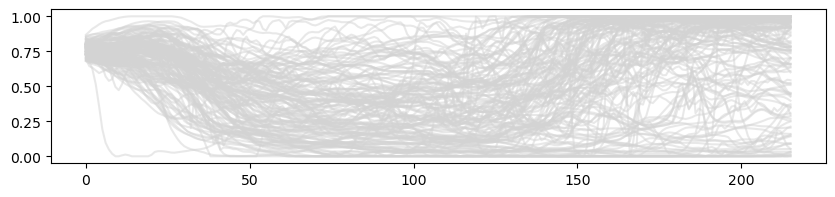

In [9]:
# Validation set identifier
hyper_         = pd.read_csv(path_to_param + f'/{resource}-{method}-params_iter_1.csv')
hyper_         = hyper_.set_index("parameter")
hyper_.columns = hyper_.columns.astype(int)
print(hyper_)

asset = 0
day = 25
time = 72

# Get functional predictors for a given test
f_     = F_ts_[day, :time, asset]
e_lin_ = E_ts_lin_[day, :, asset]
e_     = E_ts_[day, :, asset]
x_     = x_ts_[asset, :]
t      = t_ts_[day]
f_hat_ = F_ts_[day, time:, asset]

# Filter solar hours with loading solar set
idx_days_  = np.absolute(t_tr_ - day) < 7
idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

_meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                          forget_rate_f  = 1.,
                                          forget_rate_e  = 100.,
                                          length_scale_f = 0.025,
                                          length_scale_e = 10.,
                                          lookup_rate    = 100.,
                                          trust_rate     = 0.1,
                                          nu             = 0.1,
                                          gamma          = 100.,
                                          xi             = .9,
                                          kappa_min      = 120,
                                          kappa_max      = 150,
                                          idx_hours_     = idx_hours_)

print(M_.shape)
print(_meta.keys())
print(_meta['w'][_meta['idx_spatial']].shape)

plt.figure(figsize=(10, 2))
plt.plot(M_.T, color = 'lightgray', alpha = 0.5)
plt.show()

In [ ]:
def _run_parallel(day):

    file_name = f'{asset}-{day}-{time}'

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_     = x_ts_[asset, :]
    t      = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    bias_  = F_ts_[day, time:, asset] - E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) 
            + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                              forget_rate_f  = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e  = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate    = hyper_.loc['lookup_rate'][time],
                                              #trust_rate     = hyper_.loc['trust_rate'][time],
                                              trust_rate     = 0.1,
                                              #nu             = hyper_.loc['nu'][time],
                                              gamma          = hyper_.loc['gamma'][time],
                                              #gamma          = 80.,
                                              xi             = hyper_.loc['xi'][time],
                                              #xi             = 0.25,
                                              kappa_min      = hyper_.loc['kappa_min'][time],
                                              kappa_max      = hyper_.loc['kappa_max'][time], 
                                              idx_hours_     = idx_hours_)

    return [M_, f_hat_, _meta['focal_curve']]

time = 72
n_workers = 36

M_     = []
f_hat_ = []
focal_ = []
for asset in [0]]:
    with mp.Pool(processes = n_workers) as pool:
        indices_ = range(363)
        results_ = pool.map(_run_parallel, indices_)
    M_     += [result[0] for result in results_]
    f_hat_ += [result[1] for result in results_]
    focal_ += [result[2] for result in results_]
print(len(M_), len(f_hat_), len(focal_))

7260 7260 7260


In [ ]:
def _empirical_PIT(y_obs, Y_ens):
    """
    Vectorized PIT for many cases.
    obs:  shape (N,)
    preds: shape (N, M) — row i are forecast samples for case i
    returns: array (N,) with PIT values in (0,1)
    """
    y_obs = np.around(np.asarray(y_obs), 4)
    Y_ens = np.around(np.asarray(Y_ens), 4)
    N, M  = Y_ens.shape
    u_ = np.zeros((N, ))

    # Create a new random number generator
    rng = np.random.default_rng()

    for i in range(N):
        _right_ecdf = ECDF(Y_ens[i, :], side='right')
        _left_ecdf  = ECDF(Y_ens[i, :], side='left')

        u_[i,]  = _right_ecdf(y_obs[i])  
        u_[i,] -= (_right_ecdf(y_obs[i]) - _left_ecdf(y_obs[i]))*rng.random()

    return u_


U_ = []
B_ = []
J_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T)]
    J_ += [_empirical_zero_inflated_PIT(f_hat_[i], M_[i].T)]

J_ = np.array(J_)
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)   

(7260, 216) (7260, 216)


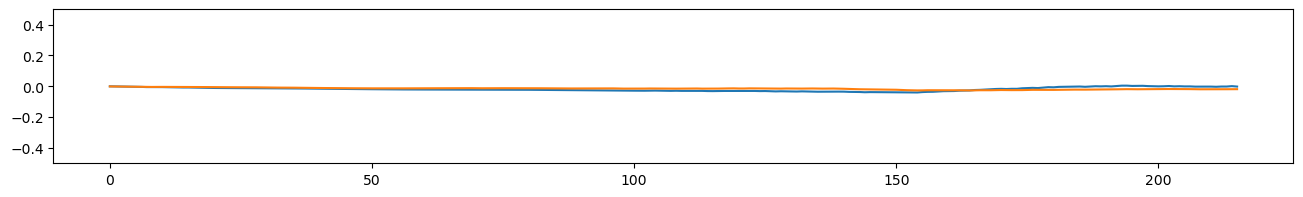

0.04026159740566815 0.027033979269039762


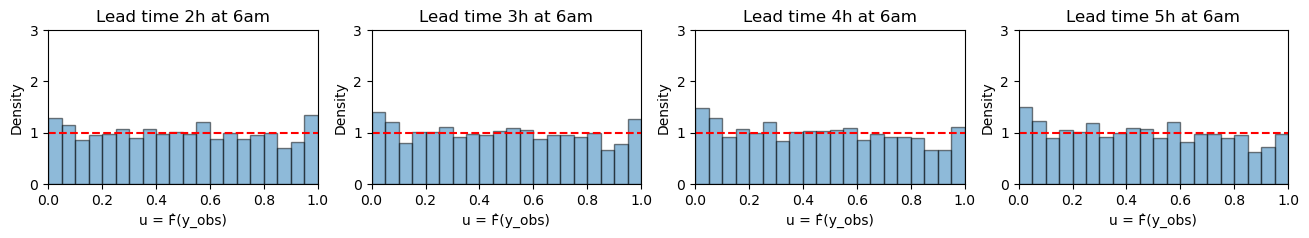

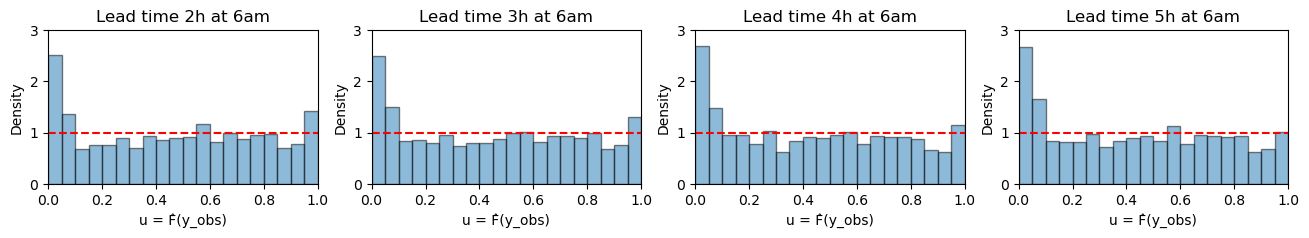

In [40]:
# idx_ = np.argsort(U_[:, 36])
# j = 0 
# i = idx_[j]

# M_p_ = M_[i]
# f_p_ = f_hat_[i]
# #print(M_p_.shape, E_p_.shape, F_p_.shape, f_p_.shape)

# print(j, (f_p_ == 0.).sum())
# print(np.around(f_p_[36], 4))
# print(np.around(np.sort(M_p_[:, 36]), 4))

# plt.figure(figsize=(10, 2))
# plt.plot(M_p_.T, color = 'lightgray', alpha = 0.5)
# plt.plot(f_p_, alpha = 0.5)
# plt.show()

# plt.figure(figsize=(10, 2))
# plt.plot(M_p_[:, 36].T, 'o', alpha = 0.5)
# plt.plot(f_p_[36], 'o',  alpha = 0.5)
# plt.show()

plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.ylim(-.5, .5)
plt.show()
print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

lead = 2
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], bins=20, title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
plt.show()

lead = 2
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
for i in range(4):
    _plot_PIT(ax[i], J_[:, (i + lead)*12], bins=20, title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
plt.show()

In [8]:
def _run_parallel(day):

    file_name = f'{asset}-{day}-{time}'

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_     = x_ts_[asset, :]
    t      = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) 
                  + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                              forget_rate_f  = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e  = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate    = hyper_.loc['lookup_rate'][time],
                                              #trust_rate     = hyper_.loc['trust_rate'][time],
                                              trust_rate     = 0.1,
                                              gamma          = hyper_.loc['gamma'][time],
                                              xi             = hyper_.loc['xi'][time],
                                              kappa_min      = hyper_.loc['kappa_min'][time],
                                              kappa_max      = hyper_.loc['kappa_max'][time], 
                                              idx_hours_     = idx_hours_)

    return [M_, f_hat_, _meta['focal_curve'], _meta['F'], _meta['E']]

time = 72
n_workers = 36

M_ = []
E_ = []
F_ = []

f_hat_ = []
focal_ = []
for asset in [0, 1, 2, 3, 4]:
    with mp.Pool(processes = n_workers) as pool:
        indices_ = range(363)
        results_ = pool.map(_run_parallel, indices_)
    M_ += [result[0] for result in results_]
    F_ += [result[3] for result in results_]
    E_ += [result[4] for result in results_]
    f_hat_ += [result[1] for result in results_]
    focal_ += [result[2] for result in results_]
print(len(M_), len(f_hat_), len(focal_), len(F_), len(E_))

U_ = []
B_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T)]
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)

KeyboardInterrupt: 

In [ ]:

plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.ylim(-.5, .5)
plt.show()
print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

lead = 2
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], bins=15, title = f'Lead time {i + lead}h at 6am')
    KS = _KS(U_[:, (i + lead)*12], nbins = 15)
    print(f'KS for lead time {i + lead}h: {KS}')
plt.show()

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 2.83829267e-04 1.13350412e-03 1.30855832e-03
 2.66129142e-03 3.38723192e-03 3.47422781e-03 4.25316941e-03
 5.46492955e-03 5.58405049e-03 5.73681757e-03 5.76481923e-03
 6.22016643e-03 6.24343901e-03 6.54787940e-03 8.72594917e-03
 8.73620751e-03 8.90348475e-03 1.19567177e-02 1.25624511e-02
 1.49303351e-02 1.56587163e-02 1.62283227e-02 1.20000000e-01
 1.40000000e-01 1.40000000e-01 1.40000000e-01 1.40000000e-01
 1.40000000e-01 1.50000000e-01 1.50000000e-01 1.60000000e-01
 1.60000000e-01 1.70000000e-01 1.80000000e-01 1.80000000e-01
 1.80000000e-01 1.800000

/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home

7260 7260 7260
(7260, 216) (7260, 216)


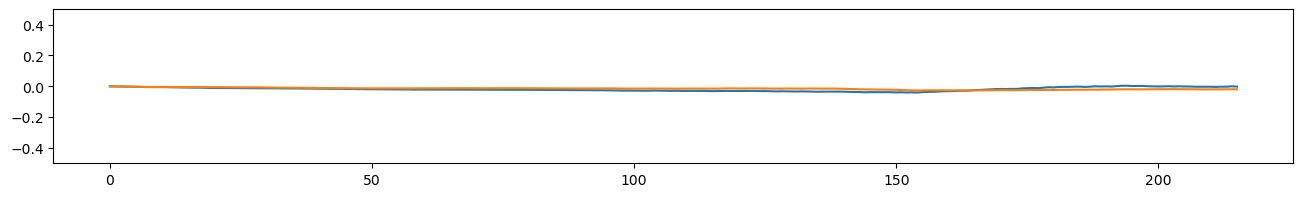

0.04063158029783668 0.02749921207711711
KS for lead time 2h: 0.05096418732782371
KS for lead time 3h: 0.04421487603305785
KS for lead time 4h: 0.03209366391184576
KS for lead time 5h: 0.03663911845730028


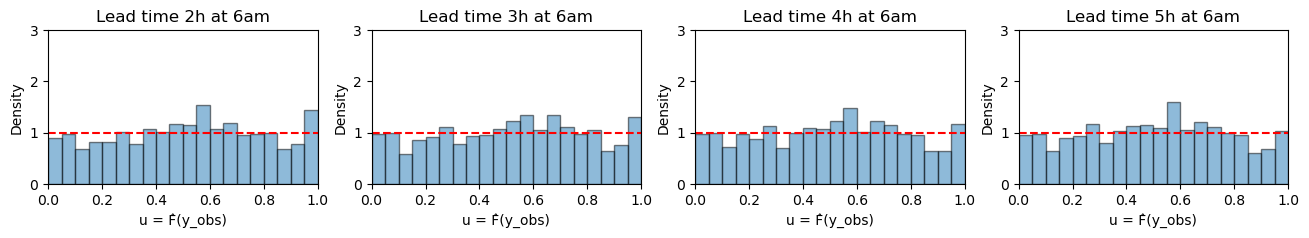

In [10]:
def _run_parallel(day):

    file_name = f'{asset}-{day}-{time}'

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_     = x_ts_[asset, :]
    t      = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    bias_  = F_ts_[day, time:, asset] - E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) 
            + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                              forget_rate_f  = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e  = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate    = hyper_.loc['lookup_rate'][time],
                                              #trust_rate     = hyper_.loc['trust_rate'][time],
                                              trust_rate     = 0.,
                                              gamma          = hyper_.loc['gamma'][time],
                                              xi             = hyper_.loc['xi'][time],
                                              kappa_min      = hyper_.loc['kappa_min'][time],
                                              kappa_max      = hyper_.loc['kappa_max'][time], 
                                              idx_hours_     = idx_hours_)

    return [M_, f_hat_, _meta['focal_curve']]

time = 72
n_workers = 36

M_     = []
f_hat_ = []
focal_ = []
for asset in range(20):
    with mp.Pool(processes = n_workers) as pool:
        indices_ = range(363)
        results_ = pool.map(_run_parallel, indices_)
    M_     += [result[0] for result in results_]
    f_hat_ += [result[1] for result in results_]
    focal_ += [result[2] for result in results_]
print(len(M_), len(f_hat_), len(focal_))

U_ = []
B_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T)]
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)   

plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.ylim(-.5, .5)
plt.show()
print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

lead = 2
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = 20, 
              title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    KS = _KS(U_[:, (i + lead)*12], nbins = 20)
    print(f'KS for lead time {i + lead}h: {KS}')
plt.show()

/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home

7260 7260 7260
(7260, 216) (7260, 216)


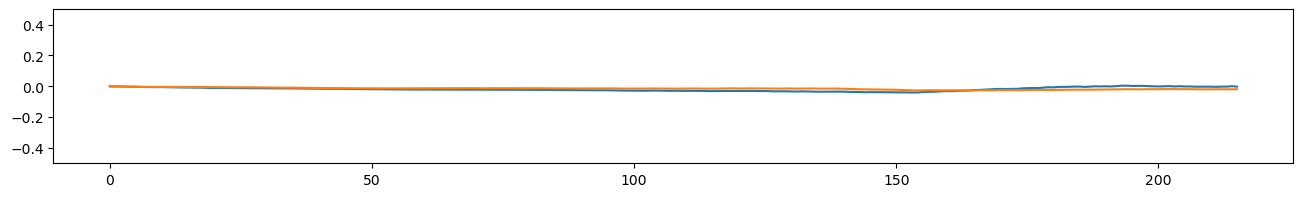

0.04050715746835182 0.027293091665748916
KS for lead time 2h: 0.041184573002754854
KS for lead time 3h: 0.0315426997245179
KS for lead time 4h: 0.03663911845730017
KS for lead time 5h: 0.039531680440771266


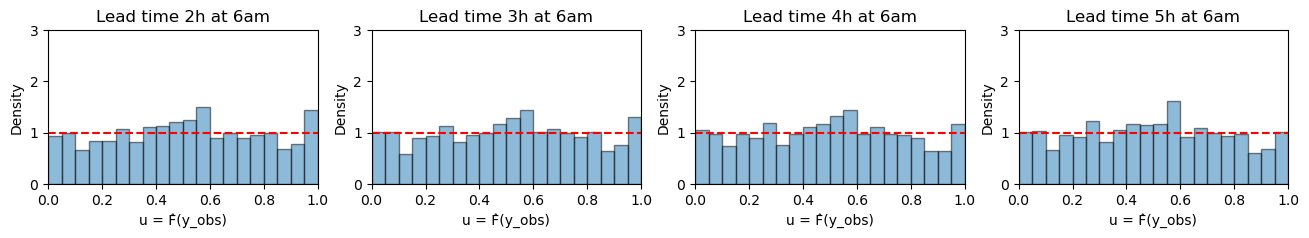

In [11]:
def _run_parallel(day):

    file_name = f'{asset}-{day}-{time}'

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_     = x_ts_[asset, :]
    t      = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    bias_  = F_ts_[day, time:, asset] - E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                              forget_rate_f  = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e  = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate    = hyper_.loc['lookup_rate'][time],
                                              #trust_rate     = hyper_.loc['trust_rate'][time],
                                              trust_rate     = 0.1,
                                              gamma          = hyper_.loc['gamma'][time],
                                              xi             = hyper_.loc['xi'][time],
                                              kappa_min      = hyper_.loc['kappa_min'][time],
                                              kappa_max      = hyper_.loc['kappa_max'][time], 
                                              idx_hours_     = idx_hours_,
                                              b = 0.6)

    return [M_, f_hat_, _meta['focal_curve']]

time = 72
n_workers = 36

M_     = []
f_hat_ = []
focal_ = []
for asset in range(20):
    with mp.Pool(processes = n_workers) as pool:
        indices_ = range(363)
        results_ = pool.map(_run_parallel, indices_)
    M_     += [result[0] for result in results_]
    f_hat_ += [result[1] for result in results_]
    focal_ += [result[2] for result in results_]
print(len(M_), len(f_hat_), len(focal_))

U_ = []
B_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T)]
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)   

plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.ylim(-.5, .5)
plt.show()
print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

lead = 2
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = 20, 
              title = f'Lead time {i + lead}h at 6am')
    ax[i].set_ylim(0, 3)
    KS = _KS(U_[:, (i + lead)*12], nbins = 20)
    print(f'KS for lead time {i + lead}h: {KS}')
plt.show()

/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home

7260 7260 7260
(7260, 216) (7260, 216)


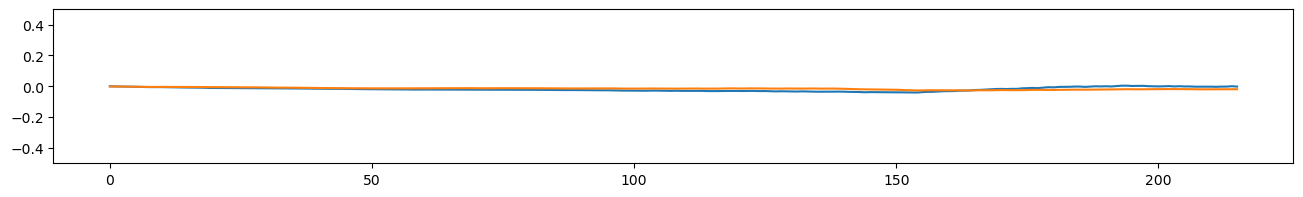

0.040462976143876644 0.027251015483186123
KS for lead time 2h: 0.034297520661157044
KS for lead time 3h: 0.026308539944903453
KS for lead time 4h: 0.04655647382920103
KS for lead time 5h: 0.05027548209366384


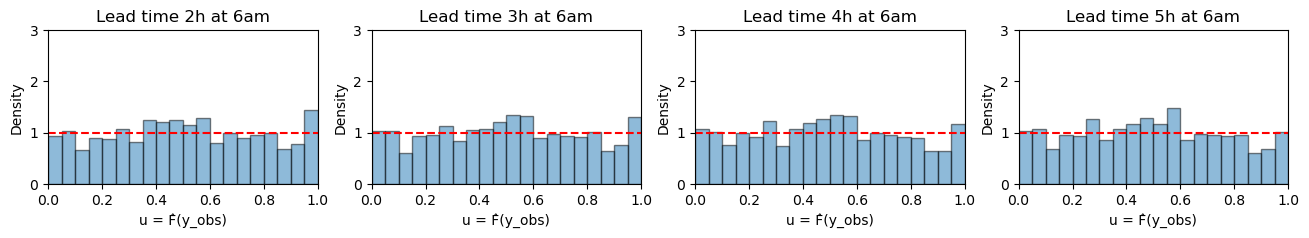

In [12]:
def _run_parallel(day):

    file_name = f'{asset}-{day}-{time}'

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_     = x_ts_[asset, :]
    t      = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    bias_  = F_ts_[day, time:, asset] - E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                              forget_rate_f  = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e  = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate    = hyper_.loc['lookup_rate'][time],
                                              #trust_rate     = hyper_.loc['trust_rate'][time],
                                              trust_rate     = 0.1,
                                              gamma          = hyper_.loc['gamma'][time],
                                              xi             = hyper_.loc['xi'][time],
                                              kappa_min      = hyper_.loc['kappa_min'][time],
                                              kappa_max      = hyper_.loc['kappa_max'][time], 
                                              idx_hours_     = idx_hours_, 
                                              b = 0.5)

    return [M_, f_hat_, _meta['focal_curve']]

time = 72
n_workers = 36

M_     = []
f_hat_ = []
focal_ = []
for asset in range(20):
    with mp.Pool(processes = n_workers) as pool:
        indices_ = range(363)
        results_ = pool.map(_run_parallel, indices_)
    M_     += [result[0] for result in results_]
    f_hat_ += [result[1] for result in results_]
    focal_ += [result[2] for result in results_]
print(len(M_), len(f_hat_), len(focal_))

U_ = []
B_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T)]
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)   

plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.ylim(-.5, .5)
plt.show()
print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

lead = 2
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = 20, 
              title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 3)
    KS = _KS(U_[:, (i + lead)*12], nbins = 20)
    print(f'KS for lead time {i + lead}h: {KS}')
plt.show()

/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home/gterren/dynamic_update/functional_forecast_dynamic_update/ffc_utils.py:313: RuntimeWarning: divide by zero encountered in scalar divide
  p0_p = b*np.nan_to_num((1. - trust_rate)/(1. - p0), 1)
/home

7260 7260 7260
(7260, 216) (7260, 216)


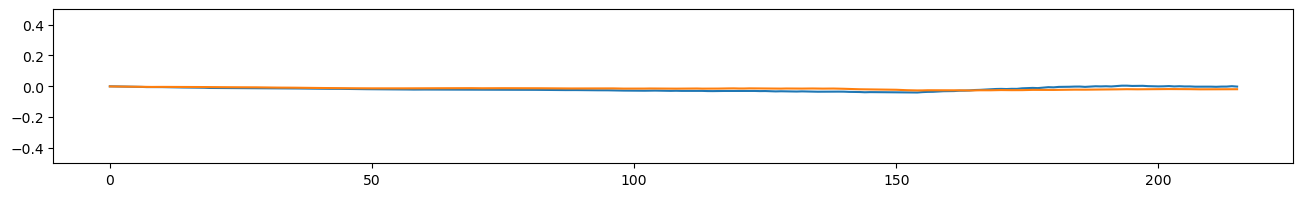

0.04041136097704069 0.02720949880567409
KS for lead time 2h: 0.021763085399449045
KS for lead time 3h: 0.034848484848484906
KS for lead time 4h: 0.05261707988980713
KS for lead time 5h: 0.048622589531680416


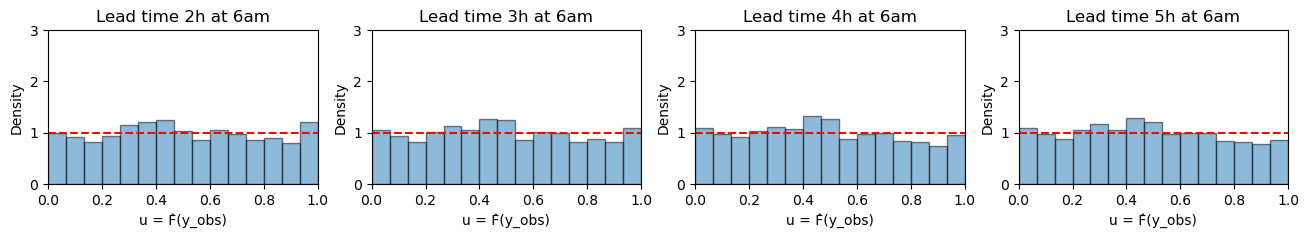

In [13]:
def _run_parallel(day):

    file_name = f'{asset}-{day}-{time}'

    # Get functional predictors for a given test
    f_     = F_ts_[day, :time, asset]
    e_lin_ = E_ts_lin_[day, :, asset]
    e_     = E_ts_[day, :, asset]
    x_     = x_ts_[asset, :]
    t      = t_ts_[day]
    f_hat_ = F_ts_[day, time:, asset]

    bias_  = F_ts_[day, time:, asset] - E_ts_[day, time:, asset]

    # Filter solar hours with loading solar set
    idx_days_  = np.absolute(t_tr_ - day) < 7
    idx_hours_ = (np.sum(F_tr_[idx_days_, :], axis = 0) + np.sum(E_tr_[idx_days_, :], axis = 0)) > 1.

    _meta, M_ = _fknn_forecast_dynamic_update(F_tr_, E_tr_lin_, x_tr_, t_tr_, dt_, f_, e_lin_, x_, t,
                                              forget_rate_f  = hyper_.loc['forget_rate_f'][time],
                                              forget_rate_e  = hyper_.loc['forget_rate_e'][time],
                                              length_scale_f = hyper_.loc['length_scale_f'][time],
                                              length_scale_e = hyper_.loc['length_scale_e'][time],
                                              lookup_rate    = hyper_.loc['lookup_rate'][time],
                                              #trust_rate     = hyper_.loc['trust_rate'][time],
                                              trust_rate     = 0.1,
                                              gamma          = hyper_.loc['gamma'][time],
                                              xi             = hyper_.loc['xi'][time],
                                              kappa_min      = hyper_.loc['kappa_min'][time],
                                              kappa_max      = hyper_.loc['kappa_max'][time], 
                                              idx_hours_     = idx_hours_, 
                                              b = 0.4)

    return [M_, f_hat_, _meta['focal_curve']]

time = 72
n_workers = 36

M_     = []
f_hat_ = []
focal_ = []
for asset in range(20):
    with mp.Pool(processes = n_workers) as pool:
        indices_ = range(363)
        results_ = pool.map(_run_parallel, indices_)
    M_     += [result[0] for result in results_]
    f_hat_ += [result[1] for result in results_]
    focal_ += [result[2] for result in results_]
print(len(M_), len(f_hat_), len(focal_))

U_ = []
B_ = []
for i in range(len(M_)):
    B_ += [f_hat_[i] - focal_[i]]
    U_ += [_empirical_PIT(f_hat_[i], M_[i].T)]
U_ = np.array(U_)
B_ = np.array(B_)
print(U_.shape, B_.shape)   

plt.figure(figsize=(16, 2))
plt.plot(np.median(B_, axis = 0))
plt.plot(np.mean(B_, axis = 0))
plt.ylim(-.5, .5)
plt.show()
print(np.absolute(np.median(B_, axis = 0)).max(), np.absolute(np.mean(B_, axis = 0)).max())

lead = 2
fig, ax = plt.subplots(1, 4, figsize=(16, 2))  
for i in range(4):
    _plot_PIT(ax[i], U_[:, (i + lead)*12], 
              bins = 15, 
              title = f'Lead time {i + lead}h at 6am')
    
    ax[i].set_ylim(0, 3)
    KS = _KS(U_[:, (i + lead)*12], nbins = 15)
    print(f'KS for lead time {i + lead}h: {KS}')
plt.show()